# Chest X-ray Pneumonia Classifier

A convolutional neural network (**ResNet-18**, transfer learning) that classifies
paediatric chest X-rays as **Normal** or **Pneumonia**, with class-imbalance handling,
proper validation, AUROC-based evaluation, and Grad-CAM explainability.

Dataset: [Chest X-ray Pneumonia (Kaggle)](https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia) — paediatric patients aged 1–5, Guangzhou.

> **Research and educational use only.** This is not a medical device and must not be used for clinical decision-making.

---
**How to run:** Colab → `Runtime → Change runtime type → T4 GPU`, then run cells top to bottom. You'll need your `kaggle.json` API key ready.

## 1. Setup
Install packages, import libraries, and **set random seeds** so every run is reproducible.

In [14]:
# Colab has most of these; this just guarantees they're present.
!pip -q install kaggle seaborn scikit-learn

In [15]:
import os, random, shutil
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

# Reproducibility: same seed -> same split, same shuffling, same results.
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

Using device: cuda


## 2. Get the data from Kaggle
Upload your `kaggle.json` when prompted, then we download and unzip the dataset.

In [16]:
from google.colab import files
files.upload()   # choose kaggle.json when the file picker appears

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"muhammedomarjee","key":"4db6b1d7c9bcd490a813a8f4e4c03182"}'}

In [17]:
os.makedirs('/root/.kaggle', exist_ok=True)
shutil.move('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)

!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia -p /content
!unzip -q -o /content/chest-xray-pneumonia.zip -d /content
!ls /content/chest_xray

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
chest-xray-pneumonia.zip: Skipping, found more recently modified local copy (use --force to force download)
chest_xray  __MACOSX  test  train  val


## 3. Data preparation

Three important choices here:

1. **ImageNet normalization.** ResNet-18 is pretrained on ImageNet, so it expects inputs normalized with the ImageNet mean/std. Skipping this wastes the pretrained features — a common silent mistake.
2. **A proper validation split.** This dataset's built-in `val/` folder contains **only 16 images**, which is too small to be meaningful. So we ignore it and carve a *stratified* 10% validation set out of the training data instead (keeping the Normal:Pneumonia ratio intact).
3. **Augmentation on training only.** Random flips/rotations help the model generalise, but we never augment the validation or test data.

In [18]:
IMG_SIZE = 224
BATCH    = 32

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

train_dir = "/content/chest_xray/train"
test_dir  = "/content/chest_xray/test"

# Two views of the SAME training folder: augmented (for training) and plain (for validation).
train_full_aug   = datasets.ImageFolder(train_dir, transform=train_tf)
train_full_plain = datasets.ImageFolder(train_dir, transform=eval_tf)
test_ds          = datasets.ImageFolder(test_dir,  transform=eval_tf)

class_names = train_full_aug.classes          # ['NORMAL', 'PNEUMONIA']
targets     = np.array(train_full_aug.targets)

# Stratified 90/10 split on indices (preserves class balance in both parts)
train_idx, val_idx = train_test_split(
    np.arange(len(targets)), test_size=0.10, stratify=targets, random_state=SEED)

train_ds = Subset(train_full_aug,   train_idx)
val_ds   = Subset(train_full_plain, val_idx)

train_dl = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=2)
val_dl   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=2)
test_dl  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=2)

print("Classes:", class_names)
print(f"Train: {len(train_ds)}   Val: {len(val_ds)}   Test: {len(test_ds)}")
print("Train class counts:", dict(zip(class_names, np.bincount(targets[train_idx]))))

Classes: ['NORMAL', 'PNEUMONIA']
Train: 4694   Val: 522   Test: 624
Train class counts: {'NORMAL': np.int64(1207), 'PNEUMONIA': np.int64(3487)}


## 4. Model + handling class imbalance
The data is roughly 1 Normal to 3 Pneumonia. Left unchecked, the model can score well just by leaning toward 'Pneumonia'. We counter this by weighting the loss by **inverse class frequency**, so mistakes on the rarer class (Normal) are penalised more.

In [19]:
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, len(class_names))   # 2 output classes
model = model.to(device)

# Inverse-frequency class weights
class_counts  = np.bincount(targets[train_idx])
class_weights = torch.tensor(class_counts.sum() / (len(class_counts) * class_counts),
                             dtype=torch.float).to(device)
print("Class weights:", dict(zip(class_names, class_weights.cpu().numpy().round(3))))

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

Class weights: {'NORMAL': np.float32(1.944), 'PNEUMONIA': np.float32(0.673)}


## 5. Training (with early stopping + saving the best model)
We train for up to 12 epochs but stop early if validation loss stops improving for 3 epochs, and we save the best-performing weights to `best_model.pth`. This gives us a reusable artifact and avoids overfitting.

In [20]:
def run_epoch(loader, training=False):
    model.train() if training else model.eval()
    total, correct, total_loss = 0, 0, 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        if training:
            optimizer.zero_grad()
        with torch.set_grad_enabled(training):
            logits = model(x)
            loss = criterion(logits, y)
            if training:
                loss.backward(); optimizer.step()
        total_loss += loss.item() * y.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += y.size(0)
    return total_loss / total, correct / total

EPOCHS, PATIENCE = 12, 3
best_val_loss, patience_left = float('inf'), PATIENCE
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_dl, training=True)
    va_loss, va_acc = run_epoch(val_dl,   training=False)
    history['train_loss'].append(tr_loss); history['val_loss'].append(va_loss)
    history['train_acc'].append(tr_acc);   history['val_acc'].append(va_acc)
    print(f"Epoch {epoch:2d}: train loss {tr_loss:.3f} acc {tr_acc:.3f} | "
          f"val loss {va_loss:.3f} acc {va_acc:.3f}")

    if va_loss < best_val_loss:
        best_val_loss, patience_left = va_loss, PATIENCE
        torch.save(model.state_dict(), "best_model.pth")
        print("   -> saved new best model")
    else:
        patience_left -= 1
        if patience_left == 0:
            print("Early stopping triggered."); break

model.load_state_dict(torch.load("best_model.pth"))
print("Reloaded best model.")

Epoch  1: train loss 0.124 acc 0.951 | val loss 0.139 acc 0.923
   -> saved new best model
Epoch  2: train loss 0.070 acc 0.975 | val loss 0.041 acc 0.983
   -> saved new best model
Epoch  3: train loss 0.047 acc 0.983 | val loss 0.049 acc 0.987
Epoch  4: train loss 0.038 acc 0.985 | val loss 0.043 acc 0.973
Epoch  5: train loss 0.031 acc 0.989 | val loss 0.056 acc 0.969
Early stopping triggered.
Reloaded best model.


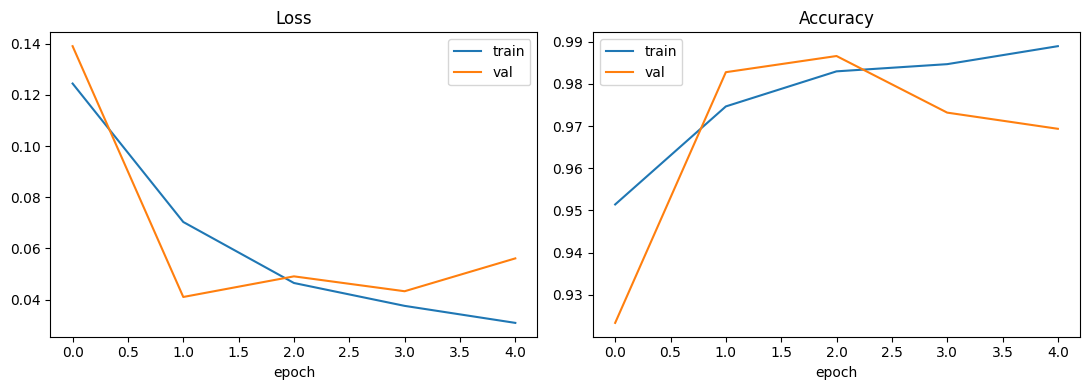

In [21]:
# Training curves
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(history['train_loss'], label='train'); ax[0].plot(history['val_loss'], label='val')
ax[0].set_title('Loss'); ax[0].set_xlabel('epoch'); ax[0].legend()
ax[1].plot(history['train_acc'], label='train'); ax[1].plot(history['val_acc'], label='val')
ax[1].set_title('Accuracy'); ax[1].set_xlabel('epoch'); ax[1].legend()
plt.tight_layout(); plt.savefig("training_curves.png", dpi=150, bbox_inches="tight"); plt.show()

## 6. Evaluation on the held-out test set

For a clinical screening task, **accuracy alone is misleading**. We report:
- **AUROC** — overall ranking ability, threshold-independent.
- **Sensitivity** — of all true pneumonia cases, how many we caught (missing these is the dangerous error).
- **Specificity** — of all true normals, how many we correctly cleared.
- Full **precision/recall/F1** per class and a confusion matrix.

In [22]:
model.eval()
all_true, all_pred, all_prob = [], [], []
with torch.no_grad():
    for x, y in test_dl:
        probs = torch.softmax(model(x.to(device)), dim=1)[:, 1]   # P(PNEUMONIA)
        all_prob.append(probs.cpu().numpy())
        all_pred.append((probs >= 0.5).long().cpu().numpy())
        all_true.append(y.numpy())

all_true = np.concatenate(all_true)
all_pred = np.concatenate(all_pred)
all_prob = np.concatenate(all_prob)

auroc = roc_auc_score(all_true, all_prob)
cm = confusion_matrix(all_true, all_pred)
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print(f"Test AUROC   : {auroc:.3f}")
print(f"Sensitivity  : {sensitivity:.3f}   (pneumonia correctly caught)")
print(f"Specificity  : {specificity:.3f}   (normal correctly cleared)")
print()
print(classification_report(all_true, all_pred, target_names=class_names, digits=3))

Test AUROC   : 0.972
Sensitivity  : 0.995   (pneumonia correctly caught)
Specificity  : 0.697   (normal correctly cleared)

              precision    recall  f1-score   support

      NORMAL      0.988     0.697     0.817       234
   PNEUMONIA      0.845     0.995     0.914       390

    accuracy                          0.883       624
   macro avg      0.917     0.846     0.866       624
weighted avg      0.899     0.883     0.878       624



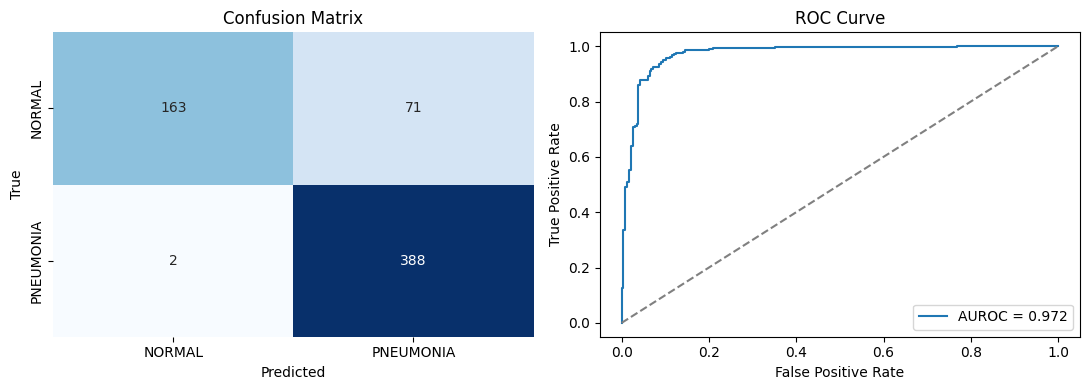

In [23]:
# Confusion matrix + ROC curve
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.heatmap(cm, annot=True, fmt='d', cbar=False, cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax[0])
ax[0].set_xlabel('Predicted'); ax[0].set_ylabel('True'); ax[0].set_title('Confusion Matrix')

fpr, tpr, _ = roc_curve(all_true, all_prob)
ax[1].plot(fpr, tpr, label=f'AUROC = {auroc:.3f}')
ax[1].plot([0, 1], [0, 1], '--', color='grey')
ax[1].set_xlabel('False Positive Rate'); ax[1].set_ylabel('True Positive Rate')
ax[1].set_title('ROC Curve'); ax[1].legend()
plt.tight_layout(); plt.savefig("evaluation.png", dpi=150, bbox_inches="tight"); plt.show()

Chosen threshold (Youden's J on validation): 0.101

Default (0.50)   | Sensitivity 0.995 | Specificity 0.697 | Accuracy 0.883
Tuned (0.10)     | Sensitivity 0.997 | Specificity 0.500 | Accuracy 0.811


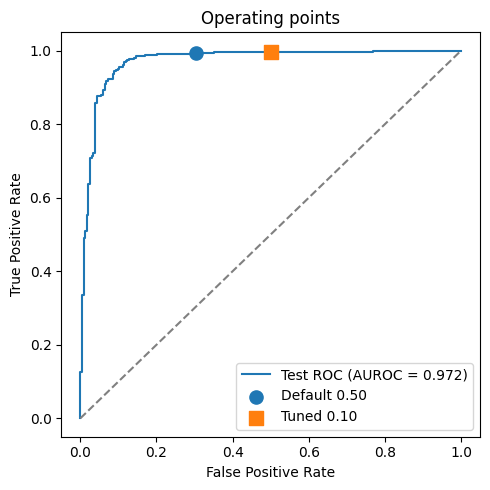

In [24]:
# --- Section 6b: Threshold tuning ---
# The default 0.5 cutoff favours sensitivity at the cost of specificity.
# We pick a better cutoff on the VALIDATION set (never the test set) using
# Youden's J, then report test performance at both the default and tuned cutoffs.

# 1) Validation probabilities
model.eval()
val_true, val_prob = [], []
with torch.no_grad():
    for x, y in val_dl:
        p = torch.softmax(model(x.to(device)), dim=1)[:, 1]
        val_prob.append(p.cpu().numpy()); val_true.append(y.numpy())
val_true = np.concatenate(val_true); val_prob = np.concatenate(val_prob)

# 2) Youden's J (maximise sensitivity + specificity - 1) on the validation ROC
v_fpr, v_tpr, v_thr = roc_curve(val_true, val_prob)
best_thr = float(v_thr[np.argmax(v_tpr - v_fpr)])
print(f"Chosen threshold (Youden's J on validation): {best_thr:.3f}\n")

# 3) Compare test performance at both cutoffs
def report(threshold):
    pred = (all_prob >= threshold).astype(int)
    cm = confusion_matrix(all_true, pred)
    tn, fp, fn, tp = cm.ravel()
    return tp/(tp+fn), tn/(tn+fp), (tp+tn)/cm.sum()

for label, thr in [("Default (0.50)", 0.5), (f"Tuned ({best_thr:.2f})", best_thr)]:
    sens, spec, acc = report(thr)
    print(f"{label:16s} | Sensitivity {sens:.3f} | Specificity {spec:.3f} | Accuracy {acc:.3f}")

# 4) Show both operating points on the test ROC
plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f'Test ROC (AUROC = {auroc:.3f})')
plt.plot([0, 1], [0, 1], '--', color='grey')
for thr, name, mark in [(0.5, 'Default 0.50', 'o'), (best_thr, f'Tuned {best_thr:.2f}', 's')]:
    pred = (all_prob >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(all_true, pred).ravel()
    plt.scatter(fp/(fp+tn), tp/(tp+fn), s=90, marker=mark, zorder=5, label=name)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('Operating points'); plt.legend(); plt.tight_layout()
plt.savefig("threshold_tuning.png", dpi=150, bbox_inches="tight"); plt.show()

## 7. Explainability — Grad-CAM

Grad-CAM highlights the image regions that most influenced the prediction. For chest X-rays this is a crucial sanity check: a good model should attend to the **lung fields**, not to text markers, borders, or scanner artifacts (a well-known 'shortcut learning' failure in CXR models). The top row shows the X-ray; the bottom row overlays the heatmap.

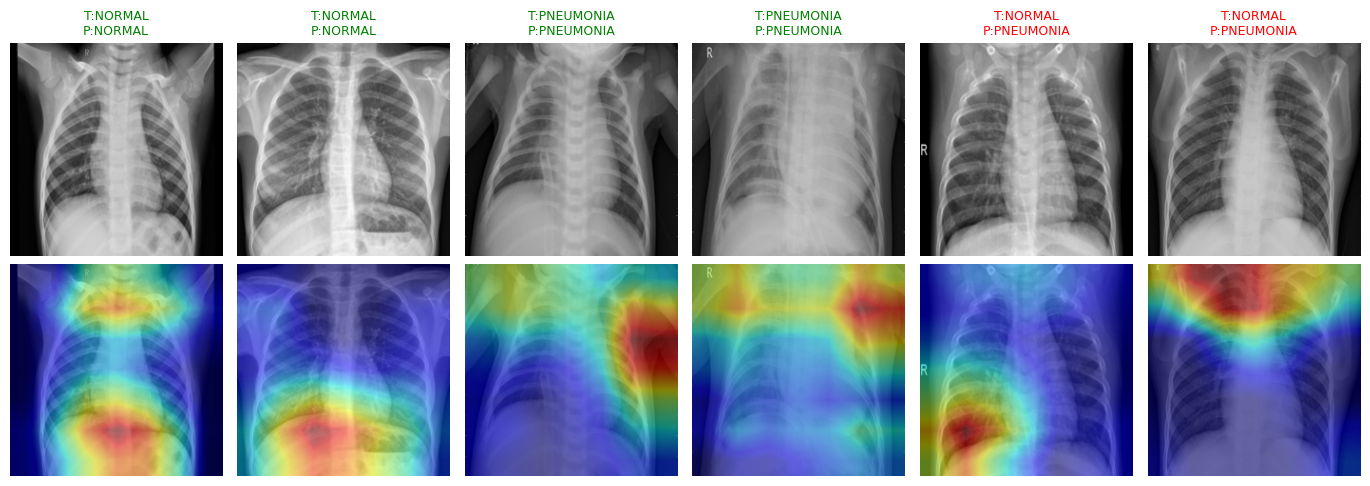

In [25]:
# Manual Grad-CAM on the last conv block (layer4)
activations, gradients = [], []
def fwd_hook(m, i, o): activations.append(o)
def bwd_hook(m, gi, go): gradients.append(go[0])

target_layer = model.layer4[-1]
h1 = target_layer.register_forward_hook(fwd_hook)
h2 = target_layer.register_full_backward_hook(bwd_hook)

def gradcam(x):                      # x: [1,3,H,W]
    activations.clear(); gradients.clear(); model.zero_grad()
    logits = model(x); cls = logits.argmax(1)
    logits[0, cls].backward()
    w = gradients[0].mean(dim=(2, 3), keepdim=True)
    cam = F.relu((w * activations[0]).sum(1, keepdim=True))
    cam = F.interpolate(cam, size=x.shape[2:], mode='bilinear', align_corners=False)
    cam = cam.squeeze().detach().cpu().numpy()
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    return cam, cls.item()

def denorm(t):                       # undo normalization for display
    m = torch.tensor(imagenet_mean).view(3, 1, 1)
    s = torch.tensor(imagenet_std).view(3, 1, 1)
    return (t.cpu() * s + m).clamp(0, 1).permute(1, 2, 0).numpy()

model.eval()
n_show = 6
idxs = random.sample(range(len(test_ds)), n_show)
fig, axes = plt.subplots(2, n_show, figsize=(2.3 * n_show, 5))
for col, idx in enumerate(idxs):
    img, true = test_ds[idx]
    cam, pred = gradcam(img.unsqueeze(0).to(device))
    disp = denorm(img)
    axes[0, col].imshow(disp); axes[0, col].axis('off')
    axes[0, col].set_title(f"T:{class_names[true]}\nP:{class_names[pred]}", fontsize=9,
                           color='green' if true == pred else 'red')
    axes[1, col].imshow(disp); axes[1, col].imshow(cam, cmap='jet', alpha=0.5)
    axes[1, col].axis('off')

h1.remove(); h2.remove()
plt.tight_layout(); plt.savefig("gradcam_grid.png", dpi=150, bbox_inches="tight"); plt.show()

## 8. Example predictions grid
A clean panel of test predictions (green = correct, red = wrong), saved as `cxr_predictions_grid.png` for the README.

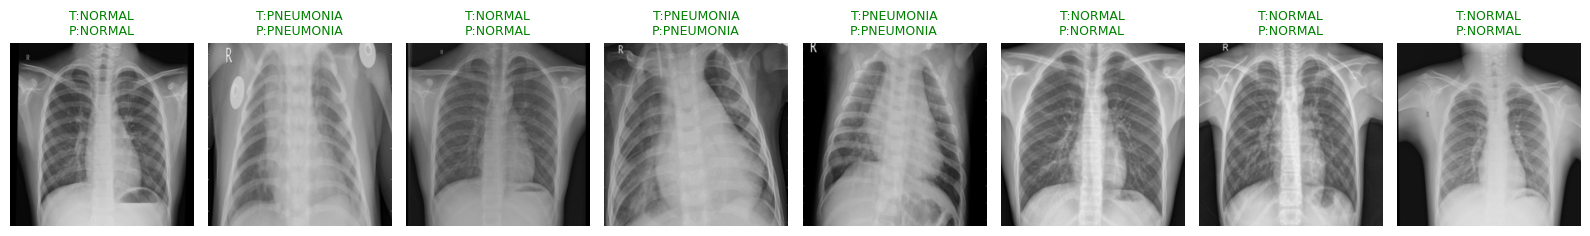

In [26]:
model.eval()
n = 8
idxs = random.sample(range(len(test_ds)), n)
fig, axes = plt.subplots(1, n, figsize=(2 * n, 3))
for ax, idx in zip(axes, idxs):
    img, true = test_ds[idx]
    with torch.no_grad():
        pred = model(img.unsqueeze(0).to(device)).argmax(1).item()
    ax.imshow(denorm(img)); ax.axis('off')
    ax.set_title(f"T:{class_names[true]}\nP:{class_names[pred]}", fontsize=9,
                 color='green' if true == pred else 'red')
plt.tight_layout(); plt.savefig("cxr_predictions_grid.png", dpi=150, bbox_inches="tight"); plt.show()

## Limitations

- **Single-source paediatric data** (one hospital, ages 1–5). Performance will not transfer directly to adults or other equipment/populations without re-validation.
- **No external validation set** — the test set comes from the same distribution as training.
- **Label noise** is possible; original labels were graded by a small number of clinicians.
- **Grad-CAM is a sanity check, not proof** of clinically valid reasoning.
- **Not validated for clinical use.** Research and educational purposes only.